# Trí tuệ nhân tạo: phân loại trực tiếp SAFE/TOXIC trên ViHSD

Ground truth được đổi **trước khi fit**: `CLEAN → SAFE`, `OFFENSIVE/HATE → TOXIC`.
Notebook hiển thị thống kê dữ liệu, metrics tổng hợp/từng lớp, confusion matrix, thời gian, lịch sử huấn luyện và phân tích lỗi.
Không hiển thị bình luận thô từ ViHSD; demo chỉ dùng câu tự tạo. Bài toán là sàng lọc ngôn từ độc hại có human review, không phải phát hiện tin giả.

**Phạm vi kết quả:** cả 5 mô hình được so sánh trên **dev** khi chạy `FULL_WITH_NEURAL`.
Chỉ **baseline đã khóa** được đánh giá trên **test** và dùng cho demo. Nhánh neural là thí nghiệm bổ sung trên train/dev, không thay đổi model đã khóa.

**Cấu trúc:** logic nằm trong `vihsd_ai/*.py`; notebook dùng để cấu hình, thử nghiệm và trình bày.
**Kết quả đã lưu:** các output bên dưới được giữ nguyên từ lần chạy trước khi tách code; chưa chạy lại phiên bản module. Mở notebook để xem, chỉ Run all khi muốn tạo thí nghiệm mới.


## 1. Cấu hình chế độ chạy
`SMOKE` chỉ dùng QA; báo cáo dùng `FULL` hoặc `FULL_WITH_NEURAL`. Nhánh neural nên chạy trên GPU.
Chạy **Runtime → Run all** từ đầu. Mỗi lần khởi tạo sẽ tạo một thư mục kết quả riêng và in đường dẫn.
Chỉ xem/trình bày kết quả đã lưu thì không cần chạy cell hay cài dependency.


In [1]:
RUN_MODE = "FULL_WITH_NEURAL"  # @param ["SMOKE", "FULL", "FULL_WITH_NEURAL"]
SEED = 42
CONFIRM_TEST_AFTER_LOCK = True
NEURAL_EPOCHS = 3
assert NEURAL_EPOCHS >= 1
assert RUN_MODE in {"SMOKE", "FULL", "FULL_WITH_NEURAL"}
print(f"RUN_MODE={RUN_MODE}, seed={SEED}")

RUN_MODE=FULL_WITH_NEURAL, seed=42


## 2. Nạp source từ repo, cài dependency và khởi tạo lần chạy
Colab cần thư mục `vihsd_ai/` cùng phiên bản notebook. Cell dưới tự clone repo nếu chưa có; với thay đổi chưa đẩy lên GitHub, upload repo mới vào `/content/cs106-ai-project` trước khi chạy.


In [2]:
from pathlib import Path
import subprocess
import sys

# Tìm thư mục chứa package vihsd_ai/.
# Dò theo thứ tự: thư mục hiện tại -> các thư mục cha -> các thư mục con một cấp.
# Nhờ dò cả thư mục con nên chỉ cần upload nguyên thư mục Code/ vào /content là chạy được.
def _find_project():
    here = Path.cwd()
    candidates = [here, *here.parents]
    try:
        candidates += sorted(d for d in here.iterdir() if d.is_dir() and not d.name.startswith("."))
    except OSError:
        pass
    # Ưu tiên bản có đủ neural_eval.py (bản mới), tránh nhầm với checkout cũ.
    for p in candidates:
        if (p / "vihsd_ai" / "neural_eval.py").exists():
            return p
    for p in candidates:
        if (p / "vihsd_ai" / "__init__.py").exists():
            return p
    return None

PROJECT_DIR = _find_project()
if PROJECT_DIR is None and Path("/content").exists():
    PROJECT_DIR = Path("/content/cs106-ai-project")
    if not PROJECT_DIR.exists():
        print("Không thấy code đã upload, đang tải từ GitHub...", flush=True)
        subprocess.run(["git", "clone", "--depth", "1",
                        "https://github.com/andrewthongle/cs106-ai-project.git", str(PROJECT_DIR)], check=True)
if PROJECT_DIR is None or not (PROJECT_DIR / "vihsd_ai").is_dir():
    raise FileNotFoundError(
        "Không tìm thấy package vihsd_ai/. Colab: upload thư mục Code/ vào /content rồi chạy lại cell này.")

# Dọn đường dẫn và module đã nạp của lần chạy trước, để không dùng nhầm bản cũ.
for stale in [q for q in sys.path if q != str(PROJECT_DIR) and (Path(q) / "vihsd_ai").is_dir()]:
    sys.path.remove(stale)
for cached in [m for m in list(sys.modules) if m == "vihsd_ai" or m.startswith("vihsd_ai.")]:
    del sys.modules[cached]
if str(PROJECT_DIR) not in sys.path:
    sys.path.insert(0, str(PROJECT_DIR))

print(f"Dùng code tại: {PROJECT_DIR}")
print(f"  neural_eval.py: {'có' if (PROJECT_DIR / 'vihsd_ai' / 'neural_eval.py').exists() else 'KHÔNG CÓ (bản cũ)'}")

requirements = "requirements-neural.txt" if RUN_MODE == "FULL_WITH_NEURAL" else "requirements.txt"
subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "-r", str(PROJECT_DIR / requirements)])

Không thấy code đã upload, đang tải từ GitHub...
Dùng code tại: /content/cs106-ai-project
  neural_eval.py: có


0

In [3]:
from vihsd_ai import RunConfig, create_run
from vihsd_ai.data import prepare_dataset, load_train_dev
from vihsd_ai.baselines import make_baselines, train_baselines, freeze_baseline, evaluate_test
from vihsd_ai.analysis import analyze_errors, predict_examples, system_decision
from vihsd_ai.neural import prepare_neural, train_bilstm, train_phobert
from vihsd_ai.neural_eval import evaluate_neural_test
from vihsd_ai.reporting import Reports

config = RunConfig(run_mode=RUN_MODE, seed=SEED, neural_epochs=NEURAL_EPOCHS)
run = create_run(config)
prepare_dataset(run)

ViHSD checksum verified
Thư mục kết quả lần chạy này: /content/vihsd_ai_outputs/20260920T101602724213Z_full_with_neural


In [4]:
reports = Reports(run)

## 3. Nạp train/dev và đổi nhãn trước khi huấn luyện
Chưa mở test tại bước này. Bảng hiển thị cả số lượng và tỷ lệ SAFE/TOXIC.

In [5]:
train_df, dev_df = load_train_dev(run)
reports.split_overview(train_df, dev_df)


Quy mô dữ liệu train/dev


split,rows,SAFE,TOXIC,TOXIC ratio
train,24048,19886,4162,0.1731
dev,2672,2190,482,0.1804


## 4. Audit dữ liệu và phân bố
Bảng thống kê chứa số lượng, nhãn gốc/nhị phân, độ dài ký tự, URL và số fingerprint duy nhất.
Histogram dùng trục X logarithm `log(1 + độ dài)` để hiển thị cả câu ngắn lẫn dài, không cắt bỏ đuôi phân bố.


Thống kê tổng hợp; độ dài tính bằng ký tự


split,rows,contains_url,empty_texts,unique_fingerprints,duplicate_rows,length_min,length_median,length_mean,length_p95,length_max
train,24048,19,2,22558,1490,0,33.0000,49.2834,136.0000,20816
dev,2672,0,0,2650,22,1,33.0000,47.9042,141.4500,583



Phân bố nhãn gốc và nhãn nhị phân


split,label_type,label,count,ratio
train,source_distribution,CLEAN,19886,0.8269
train,source_distribution,HATE,2556,0.1063
train,source_distribution,OFFENSIVE,1606,0.0668
train,binary_distribution,SAFE,19886,0.8269
train,binary_distribution,TOXIC,4162,0.1731
dev,source_distribution,CLEAN,2190,0.8196
dev,source_distribution,HATE,270,0.1010
dev,source_distribution,OFFENSIVE,212,0.0793
dev,binary_distribution,SAFE,2190,0.8196
dev,binary_distribution,TOXIC,482,0.1804


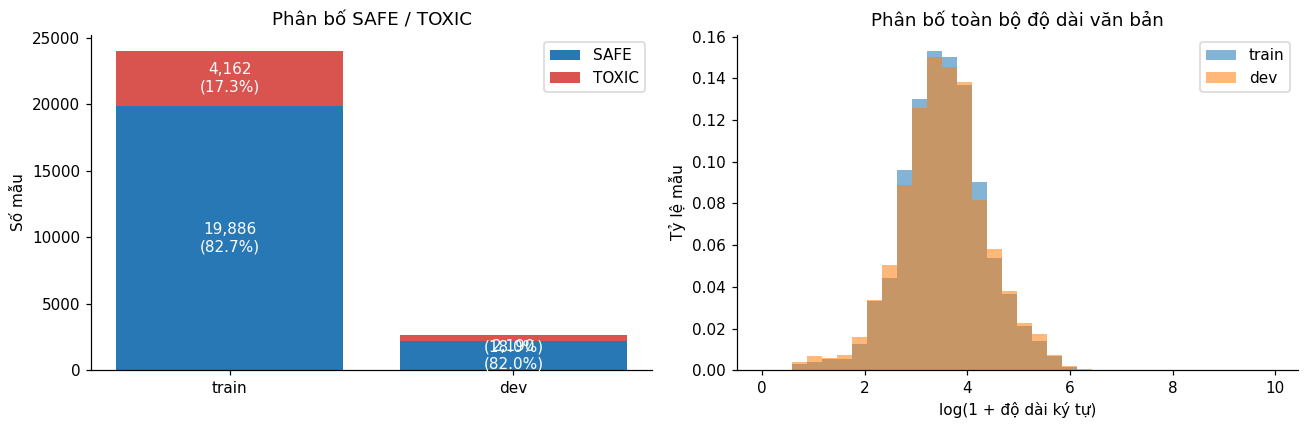

In [6]:
audit = reports.audit_train_dev(train_df, dev_df)

## 5. Tiền xử lý social text tiếng Việt
Unicode/lowercase → URL → icon/emoji → ký tự lặp → teen code → `underthesea` → stopword.
Từ phủ định được giữ. TF-IDF và từ vựng chỉ fit trên train.

In [7]:
from vihsd_ai.preprocessing import SocialPreprocessor
# Dùng SocialPreprocessor().transform([...]) để thử riêng với câu tự tạo.

## 6–7. Huấn luyện, đánh giá train/dev và chọn baseline
Xếp hạng bằng **dev Macro-F1 → dev TOXIC Recall → tên model** (không làm tròn trước khi chọn).
Hiển thị metrics đầy đủ, khoảng cách train–dev, thời gian fit/đánh giá và confusion matrix trên cả hai split.

In [8]:
# Có thể thay/thêm estimator trong models để thử nghiệm; selection vẫn dùng dev.
models = make_baselines(seed=SEED)
baselines = train_baselines(train_df, dev_df, seed=SEED, models=models)

Đang fit multinomial_nb...
multinomial_nb: fit=15.6s | dev Macro-F1=0.6808 | dev TOXIC Recall=0.2946
Đang fit logistic_regression...
logistic_regression: fit=15.2s | dev Macro-F1=0.7911 | dev TOXIC Recall=0.7656
Đang fit linear_svc...
linear_svc: fit=16.1s | dev Macro-F1=0.7923 | dev TOXIC Recall=0.7241
Baseline được chọn để khóa/test/demo: linear_svc



Xếp hạng baseline; thời gian tính bằng giây


model,train_macro_f1,dev_macro_f1,train_minus_dev_f1,dev_toxic_recall,fit_seconds,evaluation_seconds
linear_svc,0.9602,0.7923,0.1679,0.7241,16.1263,16.4925
logistic_regression,0.9148,0.7911,0.1237,0.7656,15.1772,16.8759
multinomial_nb,0.8319,0.6808,0.1511,0.2946,15.5650,17.2299



Metrics tổng hợp (thang 0–1)


model,split,samples,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
linear_svc,train,24048,0.9761,0.9411,0.9826,0.9602,0.9786,0.9761,0.9767
linear_svc,dev,2672,0.8690,0.7767,0.8125,0.7923,0.8791,0.8690,0.8730
logistic_regression,train,24048,0.9465,0.8848,0.9566,0.9148,0.9561,0.9465,0.9488
logistic_regression,dev,2672,0.8630,0.7691,0.8250,0.7911,0.8814,0.8630,0.8694
multinomial_nb,train,24048,0.9202,0.9366,0.7796,0.8319,0.9232,0.9202,0.9116
multinomial_nb,dev,2672,0.8641,0.8625,0.6421,0.6808,0.8637,0.8641,0.8355



Precision / Recall / F1 / Support từng lớp


model,split,label,precision,recall,f1,support
linear_svc,train,SAFE,0.9984,0.9727,0.9854,19886
linear_svc,train,TOXIC,0.8838,0.9926,0.9350,4162
linear_svc,dev,SAFE,0.9368,0.9009,0.9185,2190
linear_svc,dev,TOXIC,0.6166,0.7241,0.6660,482
logistic_regression,train,SAFE,0.9938,0.9412,0.9668,19886
logistic_regression,train,TOXIC,0.7757,0.9721,0.8629,4162
logistic_regression,dev,SAFE,0.9449,0.8845,0.9137,2190
logistic_regression,dev,TOXIC,0.5932,0.7656,0.6685,482
multinomial_nb,train,SAFE,0.9160,0.9947,0.9538,19886
multinomial_nb,train,TOXIC,0.9572,0.5644,0.7101,4162


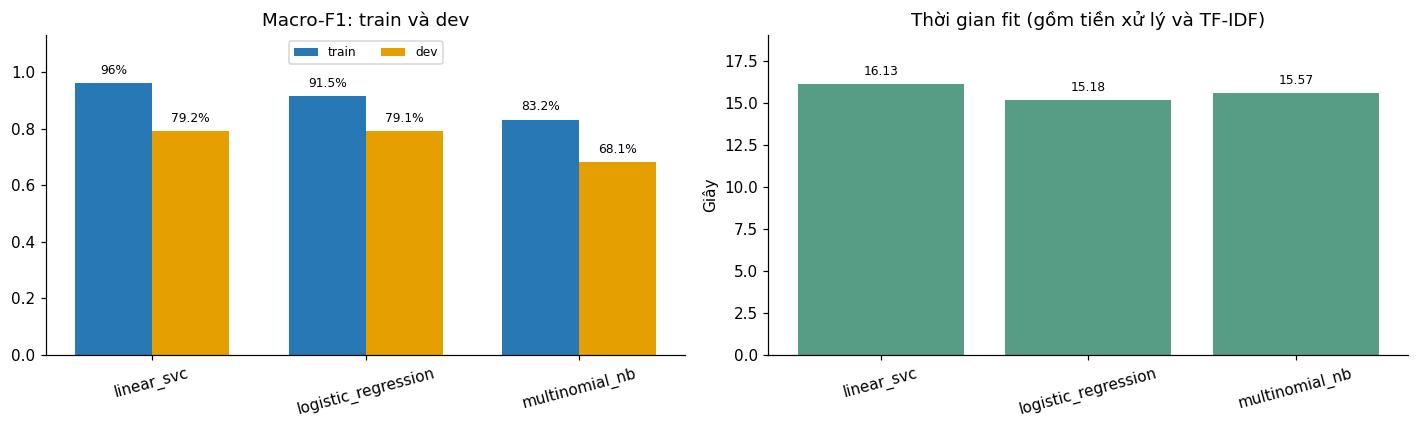

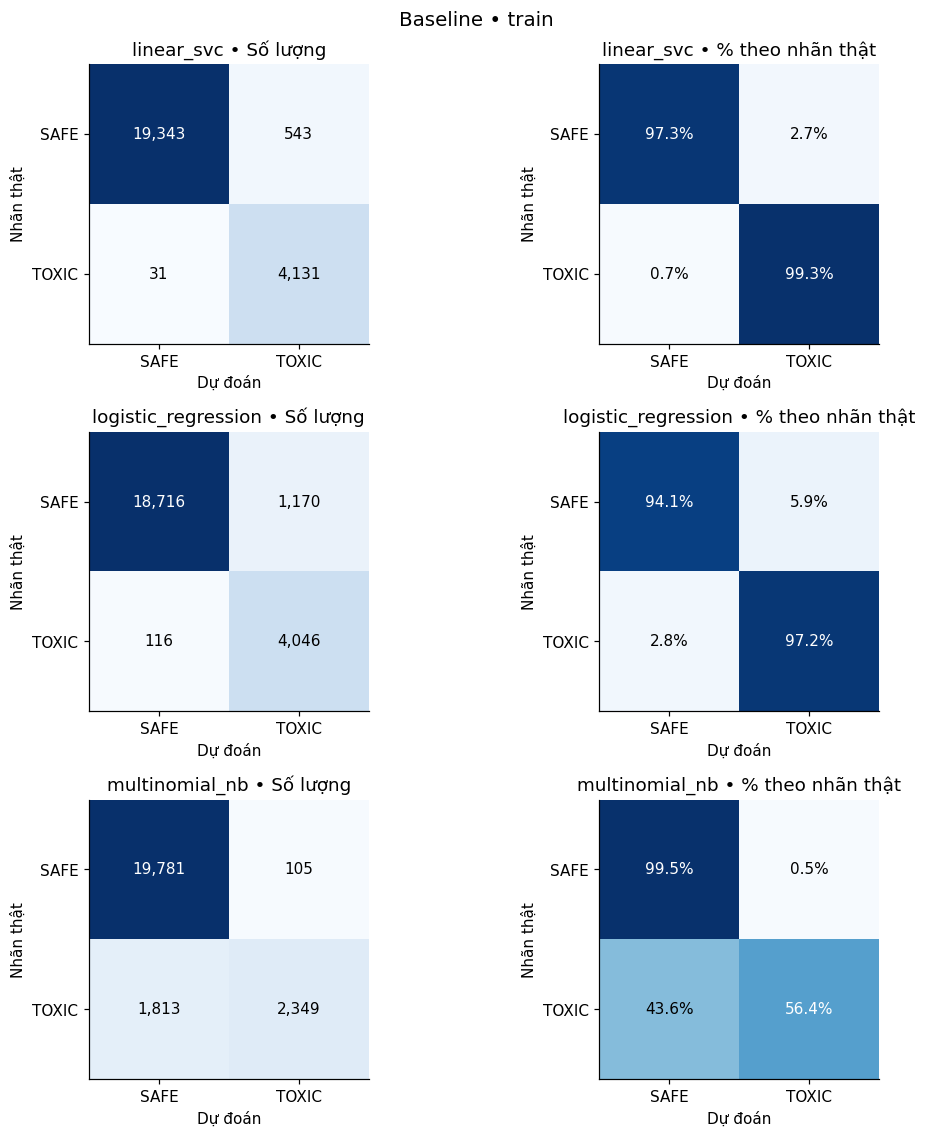

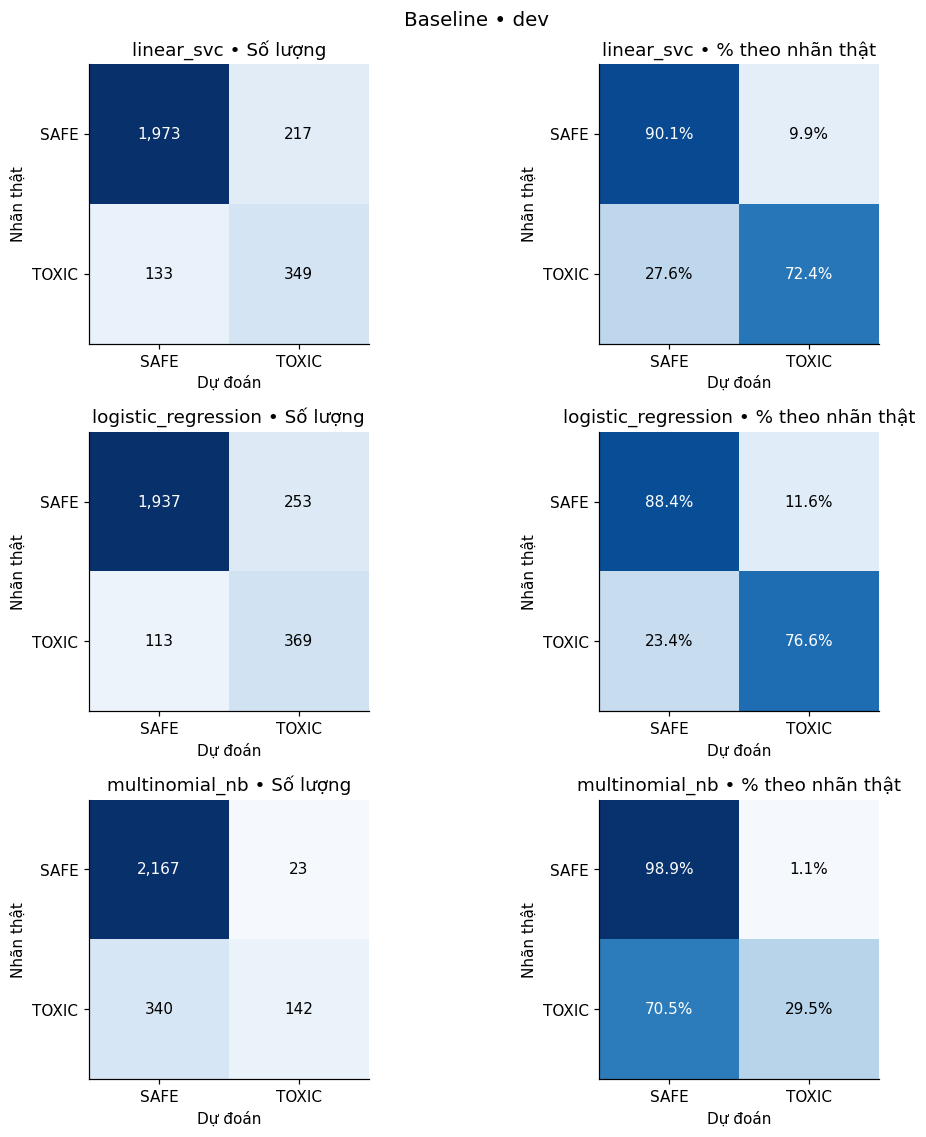

In [9]:
baseline_overview = reports.baselines(baselines)

## 8. Khóa baseline/config trước khi mở test

In [10]:
selection = freeze_baseline(run, baselines)
reports.selection(selection)

Đã khóa baseline trước khi mở test: linear_svc

Manifest lần chạy


setting,value
run_id,20260920T101602724213Z_full_with_neural
seed,42
neural_epochs,3
run_mode,FULL_WITH_NEURAL
dataset_commit,70fe50c9c94145e3b9be5614a048cbd5b480fa54
dataset_sha256,1d823c4c86a8aede83555c64da4e1be24146967aac6b30cdaf8603d4910f328d
test_loaded_during_training,False
result_status,reproduction_post_hoc
label_mapping_before_fit.CLEAN,SAFE
label_mapping_before_fit.OFFENSIVE,TOXIC



Khóa lựa chọn và checksum trước test


setting,value
locked,True
locked_before_test,True
test_opened,False
selected_model,linear_svc
artifact.path,linear_svc.joblib
artifact.sha256,5f73bb7f4ad13c850bbe937cea1fdef2e13938ba7417a17935a8882828caa81e
dev_results.path,dev_results.json
dev_results.sha256,342eab5caf208cc2231507937043fccff5fa5d32edd2d7acdf6e1d5835e0c17f


## 9–10. Test của baseline đã khóa
Tên model xuất hiện trên các bảng và biểu đồ. Test không tham gia fit hay chọn model.
Báo cáo có Accuracy, macro/weighted Precision–Recall–F1 và Precision–Recall–F1–Support của từng lớp.

TEST • linear_svc • 6,680 mẫu • dự đoán 4.73s

Thống kê tổng hợp; độ dài tính bằng ký tự


split,rows,contains_url,empty_texts,unique_fingerprints,duplicate_rows,length_min,length_median,length_mean,length_p95,length_max
test,6680,2,0,6576,104,1,33.0000,48.0138,141.0500,1762



Phân bố nhãn gốc và nhãn nhị phân


split,label_type,label,count,ratio
test,source_distribution,CLEAN,5548,0.8305
test,source_distribution,HATE,688,0.1030
test,source_distribution,OFFENSIVE,444,0.0665
test,binary_distribution,SAFE,5548,0.8305
test,binary_distribution,TOXIC,1132,0.1695


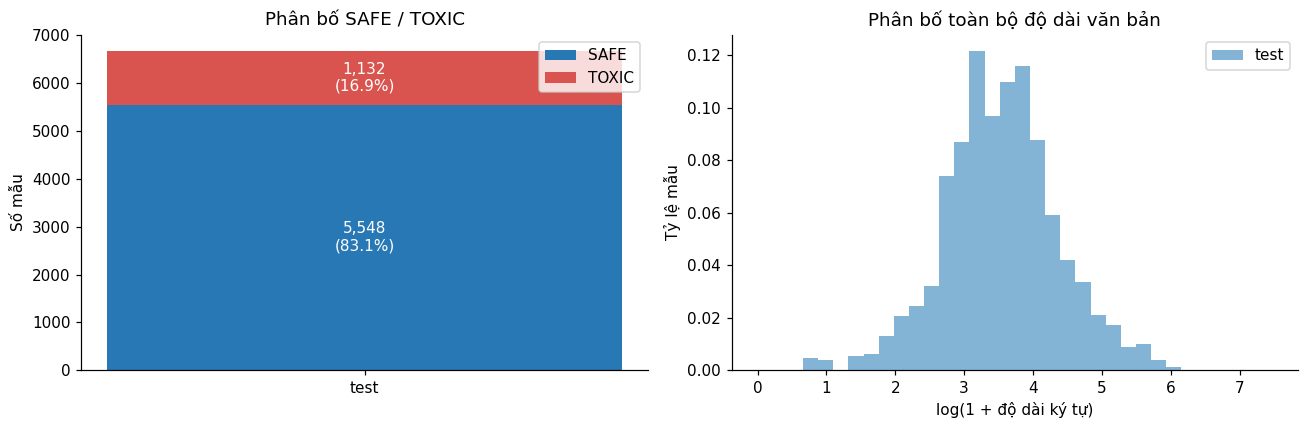


Metrics tổng hợp (thang 0–1)


model,split,samples,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
linear_svc,test,6680,0.8683,0.7654,0.7948,0.7785,0.8765,0.8683,0.8717



Precision / Recall / F1 / Support từng lớp


model,split,label,precision,recall,f1,support
linear_svc,test,SAFE,0.9335,0.9059,0.9195,5548
linear_svc,test,TOXIC,0.5972,0.6837,0.6376,1132


In [11]:
test = evaluate_test(run, confirm=CONFIRM_TEST_AFTER_LOCK)
reports.test_summary(test)

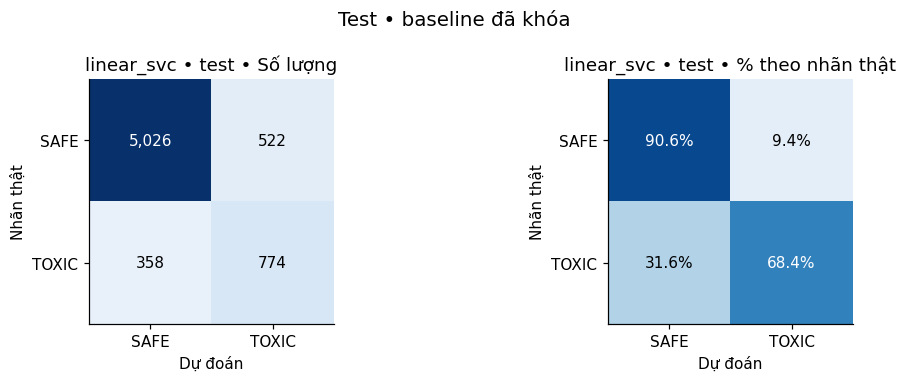

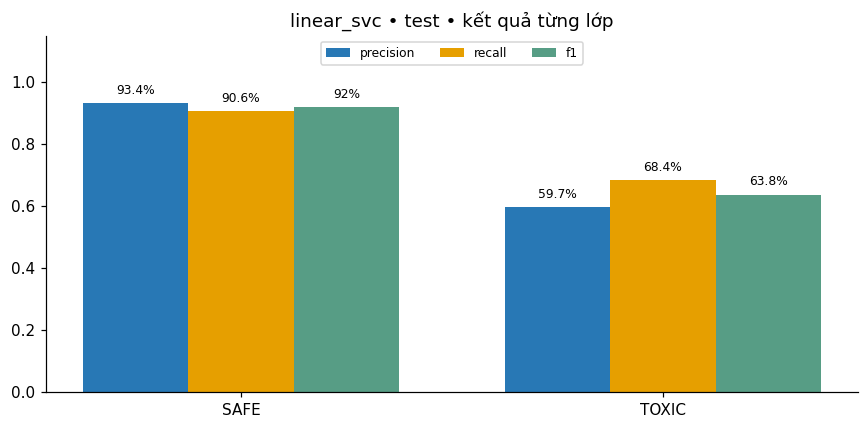

In [12]:
reports.test_plots(test)

## 11. Phân tích lỗi test
Hiển thị số lượng FP/FN, tỷ lệ tương ứng, lỗi theo độ dài và fingerprint của tối đa 20 lỗi đầu tiên.
Tỷ lệ lỗi theo nhóm luôn đi kèm số mẫu; nhóm rỗng hiển thị N/A. Không in nội dung bình luận ViHSD.


linear_svc • 880/6,680 lỗi test


outcome,count,fraction_of_test
TN: SAFE → SAFE,5026,0.7524
FP: SAFE → TOXIC,522,0.0781
FN: TOXIC → SAFE,358,0.0536
TP: TOXIC → TOXIC,774,0.1159



Tỷ lệ lỗi và mẫu số


rate,value,denominator
False positive rate: FP / số SAFE thật,0.0941,5548
False negative rate: FN / số TOXIC thật,0.3163,1132
Error rate: (FP+FN) / toàn bộ test,0.1317,6680



Lỗi theo độ dài ký tự


length_chars,samples,errors,error_rate
0–50,4715,498,0.1056
51–100,1325,230,0.1736
101–200,493,117,0.2373
201–500,145,34,0.2345
>500,2,1,0.5000



Tối đa 20 lỗi đầu tiên (định danh bằng fingerprint)


fingerprint_prefix,truth,prediction,length_chars
80480095bee5bd06,SAFE,TOXIC,32
fff22636d97bf2b3,TOXIC,SAFE,12
585a23f8c740e503,SAFE,TOXIC,18
3dedb62caa9cd9bf,TOXIC,SAFE,85
2749840ed10675f0,SAFE,TOXIC,73
7380e7f5760ccb5a,TOXIC,SAFE,31
7a481e843079c9e8,SAFE,TOXIC,12
25937a5fb94f42eb,SAFE,TOXIC,38
690ea432f093be2a,SAFE,TOXIC,4
c9d8b26897538077,SAFE,TOXIC,15


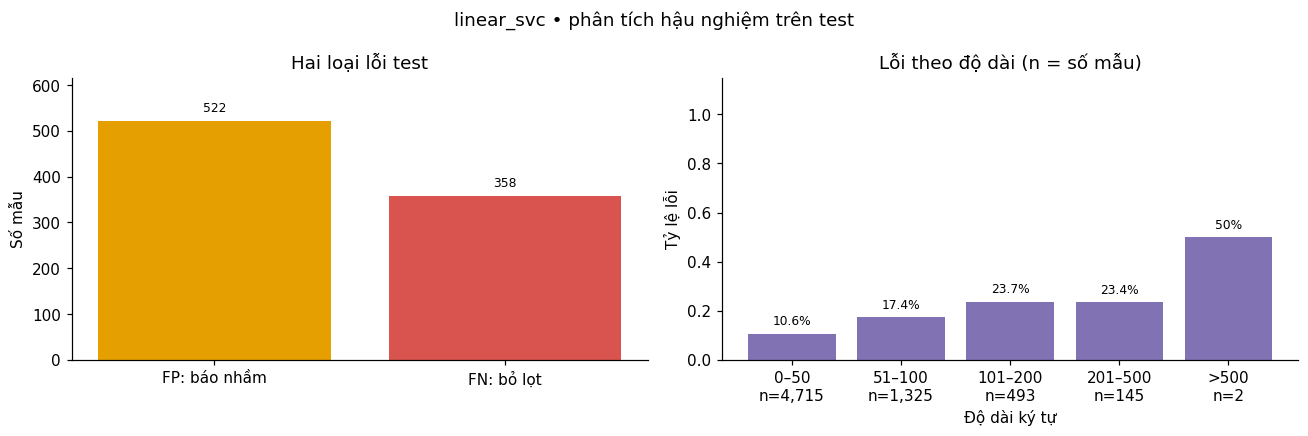

In [13]:
errors = analyze_errors(test)
reports.errors(errors)

## 12. Demo hệ thống bằng câu tự tạo
Demo dùng **baseline đã khóa**, không tự chuyển sang model đứng đầu bảng dev.
`confidence_proxy` là điểm hỗ trợ quyết định, **chưa phải xác suất đúng đã hiệu chỉnh**; đặc biệt với LinearSVC, đây là sigmoid của decision score.


Demo • linear_svc • câu tự tạo, không phải dữ liệu test


example,synthetic_text,model,prediction,confidence_proxy,warning_level,human_review,warning
DEMO-01,"Hôm nay trời đẹp quá, chúc mọi người một ngày vui vẻ!",linear_svc,SAFE,0.7967,LOW,False,Cho phép báo cáo thủ công
DEMO-02,"Dịch vụ bên bạn quá tệ, tôi rất thất vọng về cách xử lý khiếu nại.",linear_svc,SAFE,0.7680,LOW,False,Cho phép báo cáo thủ công
DEMO-03,"Mày ngu vừa thôi, có mỗi việc này cũng không làm xong.",linear_svc,TOXIC,0.5906,MEDIUM,True,Chuyển human review
DEMO-04,Bài viết này phân tích rất hay và có góc nhìn mới mẻ.,linear_svc,SAFE,0.6554,LOW,False,Cho phép báo cáo thủ công
DEMO-05,Tôi không đồng ý với ý kiến này nhưng vẫn tôn trọng bạn.,linear_svc,SAFE,0.7018,LOW,False,Cho phép báo cáo thủ công


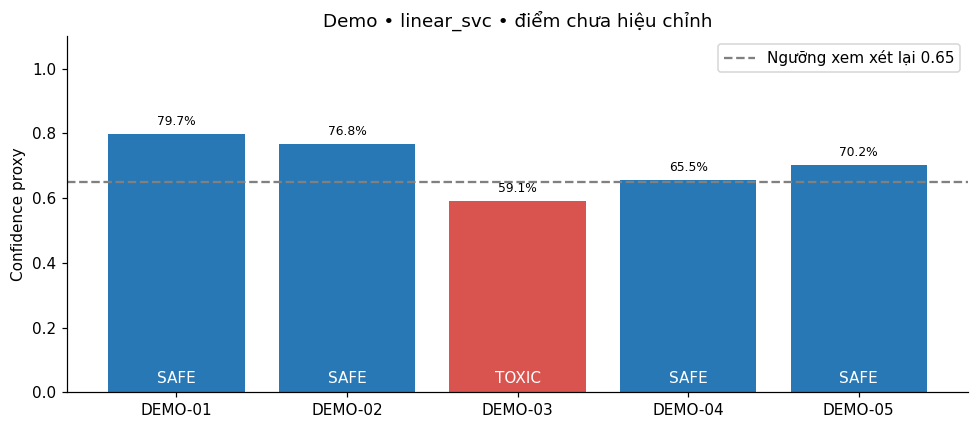

In [14]:
# Chỉnh danh sách câu tự tạo để thử hệ thống; test.model là baseline đã khóa.
sample_sentences = [
    "Hôm nay trời đẹp quá, chúc mọi người một ngày vui vẻ!",
    "Dịch vụ bên bạn quá tệ, tôi rất thất vọng về cách xử lý khiếu nại.",
    "Mày ngu vừa thôi, có mỗi việc này cũng không làm xong.",
    "Bài viết này phân tích rất hay và có góc nhìn mới mẻ.",
    "Tôi không đồng ý với ý kiến này nhưng vẫn tôn trọng bạn."
]
demo_results = predict_examples(test.model, test.model_name, sample_sentences)
reports.demo(test.model_name, demo_results)

## 13. Neural: lịch sử huấn luyện BiLSTM / PhoBERT trên train/dev
Mỗi epoch lưu **loss tối ưu trung bình**, **train/dev loss ở chế độ eval**, metrics train/dev đầy đủ và thời gian.
Loss train/eval và dev/eval được đo sau epoch với cùng checkpoint để so sánh; việc đánh giá train làm tăng thời gian chạy.
Chọn checkpoint bằng dev Macro-F1 → dev TOXIC Recall. Lưu history sau mỗi epoch để giữ tiến độ nếu lần chạy bị gián đoạn.
Nhánh này không đọc test; kết quả test trước đó vẫn thuộc baseline đã khóa.

In [15]:
neural = prepare_neural(run, train_df, dev_df)

Neural device: cuda • Tesla T4


### 13.1. BiLSTM

In [16]:
bilstm_result = train_bilstm(neural, learning_rate=2e-4)

BiLSTM: nhúng từ Word2Vec phủ 9130/9132 từ vựng (100.0%), 4.9s
BiLSTM: trọng số lớp SAFE=0.605, TOXIC=2.889
BiLSTM epoch 1: batch 250/752
BiLSTM epoch 1: batch 500/752
BiLSTM epoch 1: batch 750/752
bilstm epoch 1/3 | train loss=0.4419, dev loss=0.4664 | train F1=0.7483, dev F1=0.7321 | dev TOXIC Recall=0.7510 | 8.3s
BiLSTM epoch 2: batch 250/752
BiLSTM epoch 2: batch 500/752
BiLSTM epoch 2: batch 750/752
bilstm epoch 2/3 | train loss=0.3511, dev loss=0.4288 | train F1=0.8079, dev F1=0.7585 | dev TOXIC Recall=0.7573 | 7.9s
BiLSTM epoch 3: batch 250/752
BiLSTM epoch 3: batch 500/752
BiLSTM epoch 3: batch 750/752
bilstm epoch 3/3 | train loss=0.2763, dev loss=0.4378 | train F1=0.8487, dev F1=0.7737 | dev TOXIC Recall=0.7386 | 8.0s
BiLSTM: đã lưu checkpoint tốt nhất ở epoch 3


### 13.2. PhoBERT

In [17]:
phobert_result = train_phobert(neural, learning_rate=2e-5)

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:104: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


config.json:   0%|          | 0.00/678 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/540M [00:00<?, ?B/s]

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at vinai/phobert-base-v2 and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


PhoBERT: trọng số lớp SAFE=0.605, TOXIC=2.889


model.safetensors:   0%|          | 0.00/540M [00:00<?, ?B/s]

PhoBERT epoch 1: batch 250/1503
PhoBERT epoch 1: batch 500/1503
PhoBERT epoch 1: batch 750/1503
PhoBERT epoch 1: batch 1000/1503
PhoBERT epoch 1: batch 1250/1503
PhoBERT epoch 1: batch 1500/1503
phobert epoch 1/3 | train loss=0.2886, dev loss=0.3620 | train F1=0.8396, dev F1=0.8101 | dev TOXIC Recall=0.8195 | 330.9s
PhoBERT epoch 2: batch 250/1503
PhoBERT epoch 2: batch 500/1503
PhoBERT epoch 2: batch 750/1503
PhoBERT epoch 2: batch 1000/1503
PhoBERT epoch 2: batch 1250/1503
PhoBERT epoch 2: batch 1500/1503
phobert epoch 2/3 | train loss=0.2689, dev loss=0.5371 | train F1=0.9010, dev F1=0.8323 | dev TOXIC Recall=0.7324 | 339.2s
PhoBERT epoch 3: batch 250/1503
PhoBERT epoch 3: batch 500/1503
PhoBERT epoch 3: batch 750/1503
PhoBERT epoch 3: batch 1000/1503
PhoBERT epoch 3: batch 1250/1503
PhoBERT epoch 3: batch 1500/1503
phobert epoch 3/3 | train loss=0.2041, dev loss=0.5453 | train F1=0.9183, dev F1=0.8327 | dev TOXIC Recall=0.7593 | 337.9s
PhoBERT: đã lưu checkpoint tốt nhất ở epoch 3


### 13.3. Đường học và kết quả neural tại epoch tốt nhất


Thông tin lần chạy neural


run_id,device,preprocessing_seconds,status
20260920T101602724213Z_full_with_neural,cuda,16.2048,completed



Checkpoint tốt nhất, cấu hình và thời gian neural


model,best_epoch,fit_seconds,evaluation_seconds,total_seconds,vocabulary_size,max_length,epochs_ran,stopped_early,embedding,hyperparameters,checkpoint,resolved_revision
bilstm,3,19.1271,5.0818,35.9891,9132.0000,128,3,False,"{'used': True, 'algorithm': 'word2vec_skipgram', 'corpus': 'train split đã tiền xử lý', 'vector_size': 128, 'window': 5, 'min_count': 2, 'epochs': 5, 'seed': 42, 'vocabulary_covered': 9130, 'vocabulary_size': 9132, 'coverage_ratio': 0.9997809899255365, 'train_seconds': 4.858911450999983}","{'learning_rate': 0.0002, 'batch_size': 32, 'max_length': 128, 'embedding_dim': 128, 'hidden_size': 96, 'dropout': 0.3, 'min_count': 2, 'weight_decay': 0.01, 'patience': 2, 'grad_clip': 1.0, 'packed_sequence': True, 'class_weights': {'SAFE': 0.6046464849642965, 'TOXIC': 2.888995675156175}}",—,—
phobert,3,773.0971,234.9445,1052.5807,—,128,3,False,—,"{'learning_rate': 2e-05, 'batch_size': 16, 'max_length': 128, 'weight_decay': 0.01, 'warmup_ratio': 0.1, 'patience': 2, 'grad_clip': 1.0, 'scheduler': 'linear_warmup_decay', 'class_weights': {'SAFE': 0.6046464849642965, 'TOXIC': 2.888995675156175}}",vinai/phobert-base-v2,86cd7fd4c148980922ac11a2cf5e257f2ba639e1



Toàn bộ lịch sử epoch; loss/metrics train và dev đo sau mỗi epoch


model,epoch,optimization_loss,train_loss,dev_loss,train_macro_f1,dev_macro_f1,dev_accuracy,dev_toxic_recall,fit_seconds,evaluation_seconds,epoch_seconds
bilstm,1,0.5376,0.4419,0.4664,0.7483,0.7321,0.8099,0.7510,6.6612,1.6732,8.3344
bilstm,2,0.4184,0.3511,0.4288,0.8079,0.7585,0.8346,0.7573,6.2783,1.6013,7.8796
bilstm,3,0.3416,0.2763,0.4378,0.8487,0.7737,0.8510,0.7386,6.1876,1.8073,7.9949
phobert,1,0.4834,0.2886,0.3620,0.8396,0.8101,0.8735,0.8195,253.0550,77.8174,330.8724
phobert,2,0.3503,0.2689,0.5371,0.9010,0.8323,0.9001,0.7324,260.2455,78.9960,339.2415
phobert,3,0.2920,0.2041,0.5453,0.9183,0.8327,0.8978,0.7593,259.7966,78.1311,337.9277



Metrics tổng hợp (thang 0–1)


model,split,samples,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
bilstm epoch 1,train,24048,0.8276,0.7234,0.8046,0.7483,0.8687,0.8276,0.8407
bilstm epoch 1,dev,2672,0.8099,0.7101,0.7869,0.7321,0.8555,0.8099,0.8244
bilstm epoch 2,train,24048,0.8737,0.7794,0.8578,0.8079,0.8988,0.8737,0.8814
bilstm epoch 2,dev,2672,0.8346,0.7350,0.8044,0.7585,0.8667,0.8346,0.8451
bilstm epoch 3,train,24048,0.9028,0.8194,0.8942,0.8487,0.9200,0.9028,0.9078
bilstm epoch 3,dev,2672,0.8510,0.7526,0.8072,0.7737,0.8713,0.8510,0.8583
phobert epoch 1,train,24048,0.8965,0.8105,0.8858,0.8396,0.9152,0.8965,0.9021
phobert epoch 1,dev,2672,0.8735,0.7843,0.8524,0.8101,0.8947,0.8735,0.8802
phobert epoch 2,train,24048,0.9419,0.8919,0.9110,0.9010,0.9437,0.9419,0.9426
phobert epoch 2,dev,2672,0.9001,0.8299,0.8347,0.8323,0.9008,0.9001,0.9004



Precision / Recall / F1 / Support từng lớp


model,split,label,precision,recall,f1,support
bilstm epoch 1,train,SAFE,0.9456,0.8398,0.8896,19886
bilstm epoch 1,train,TOXIC,0.5013,0.7693,0.6070,4162
bilstm epoch 1,dev,SAFE,0.9376,0.8228,0.8765,2190
bilstm epoch 1,dev,TOXIC,0.4827,0.7510,0.5877,482
bilstm epoch 2,train,SAFE,0.9620,0.8821,0.9203,19886
bilstm epoch 2,train,TOXIC,0.5968,0.8335,0.6955,4162
bilstm epoch 2,dev,SAFE,0.9410,0.8516,0.8941,2190
bilstm epoch 2,dev,TOXIC,0.5290,0.7573,0.6229,482
bilstm epoch 3,train,SAFE,0.9733,0.9073,0.9392,19886
bilstm epoch 3,train,TOXIC,0.6655,0.8811,0.7583,4162


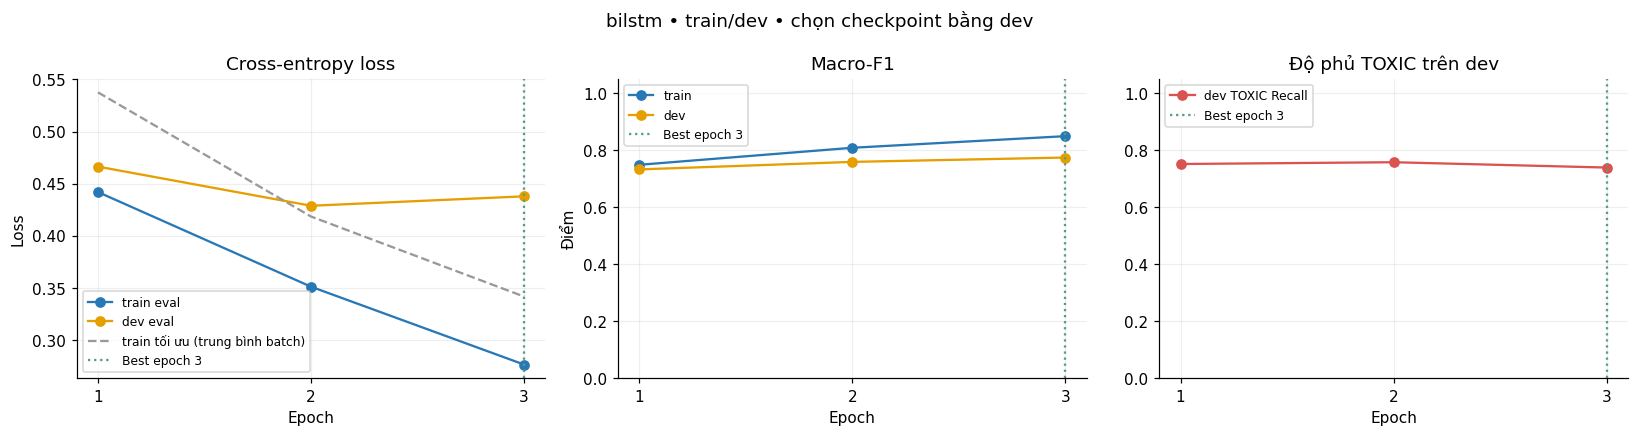


Metrics tổng hợp (thang 0–1)


model,split,samples,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
bilstm,train,24048,0.9028,0.8194,0.8942,0.8487,0.9200,0.9028,0.9078
bilstm,dev,2672,0.8510,0.7526,0.8072,0.7737,0.8713,0.8510,0.8583



Precision / Recall / F1 / Support từng lớp


model,split,label,precision,recall,f1,support
bilstm,train,SAFE,0.9733,0.9073,0.9392,19886
bilstm,train,TOXIC,0.6655,0.8811,0.7583,4162
bilstm,dev,SAFE,0.9384,0.8758,0.9060,2190
bilstm,dev,TOXIC,0.5669,0.7386,0.6414,482


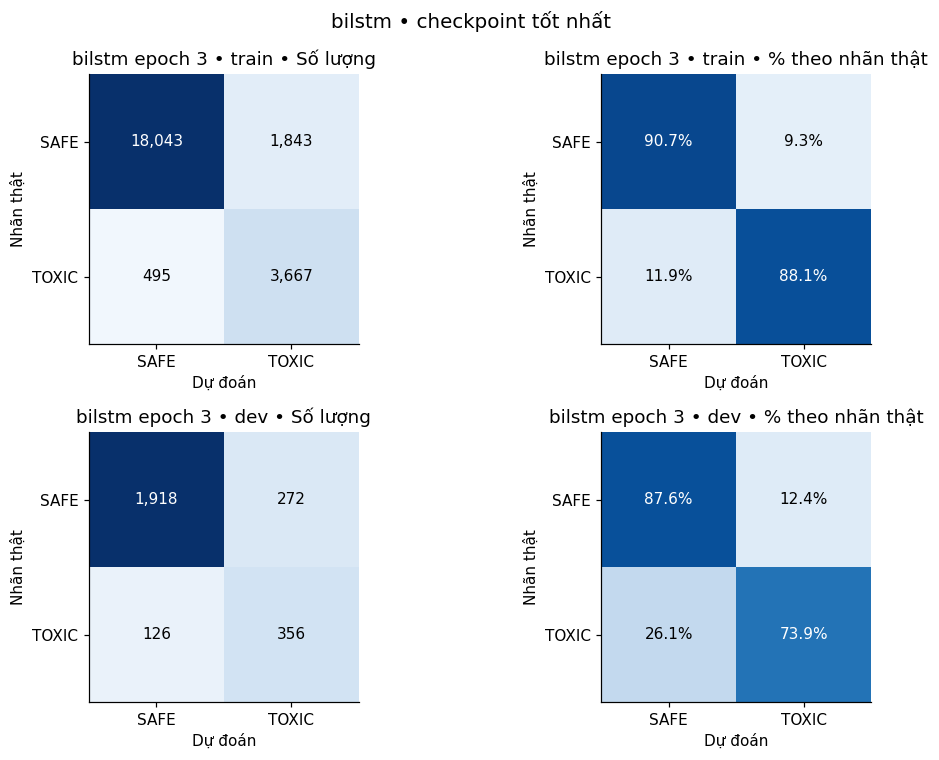

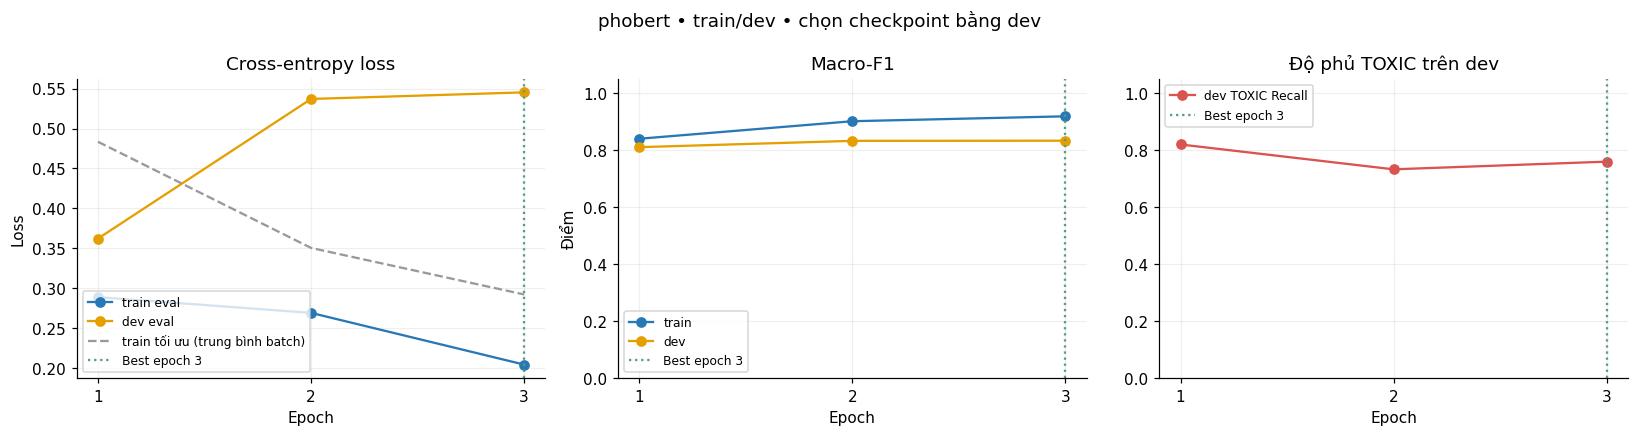


Metrics tổng hợp (thang 0–1)


model,split,samples,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
phobert,train,24048,0.9513,0.9032,0.9356,0.9183,0.9541,0.9513,0.9522
phobert,dev,2672,0.8978,0.8229,0.8438,0.8327,0.9016,0.8978,0.8994



Precision / Recall / F1 / Support từng lớp


model,split,label,precision,recall,f1,support
phobert,train,SAFE,0.9811,0.9596,0.9702,19886
phobert,train,TOXIC,0.8253,0.9116,0.8663,4162
phobert,dev,SAFE,0.9460,0.9283,0.9371,2190
phobert,dev,TOXIC,0.6998,0.7593,0.7284,482


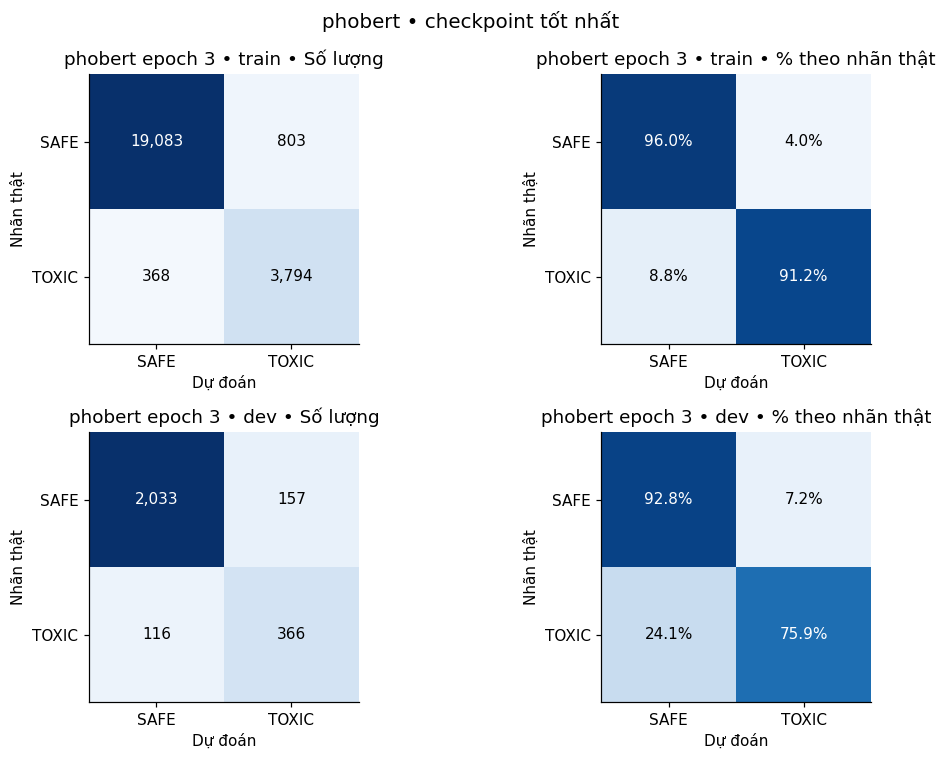

In [18]:
reports.neural(neural)

### 13.4. Neural trên tập test

Mở test **sau khi** đã khóa lựa chọn ở mục 8. Epoch tốt nhất và ngưỡng quyết định
đều được chọn bằng tập dev; test chỉ dùng để báo cáo, không dùng để chọn lại.


In [19]:
neural_test = evaluate_neural_test(neural, confirm=CONFIRM_TEST_AFTER_LOCK)

bilstm • test Accuracy=0.8576 | Macro-F1=0.7748 | TOXIC Recall=0.7412
phobert • test Accuracy=0.8915 | Macro-F1=0.8152 | TOXIC Recall=0.7350



Metrics tổng hợp (thang 0–1)


model,split,samples,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
bilstm @0.5,test,6680,0.8576,0.7520,0.8113,0.7748,0.8786,0.8576,0.8651
bilstm @0.65,test,6680,0.8820,0.7898,0.7950,0.7924,0.8831,0.8820,0.8826
phobert @0.5,test,6680,0.8915,0.8033,0.8292,0.8152,0.8968,0.8915,0.8937
phobert @0.65,test,6680,0.8948,0.8108,0.8231,0.8167,0.8970,0.8948,0.8958



Precision / Recall / F1 / Support từng lớp


model,split,label,precision,recall,f1,support
bilstm @0.5,test,SAFE,0.9435,0.8814,0.9114,5548
bilstm @0.5,test,TOXIC,0.5605,0.7412,0.6383,1132
bilstm @0.65,test,SAFE,0.9310,0.9266,0.9288,5548
bilstm @0.65,test,TOXIC,0.6485,0.6634,0.6559,1132
phobert @0.5,test,SAFE,0.9447,0.9234,0.9339,5548
phobert @0.5,test,TOXIC,0.6619,0.7350,0.6965,1132
phobert @0.65,test,SAFE,0.9412,0.9315,0.9363,5548
phobert @0.65,test,TOXIC,0.6804,0.7147,0.6971,1132


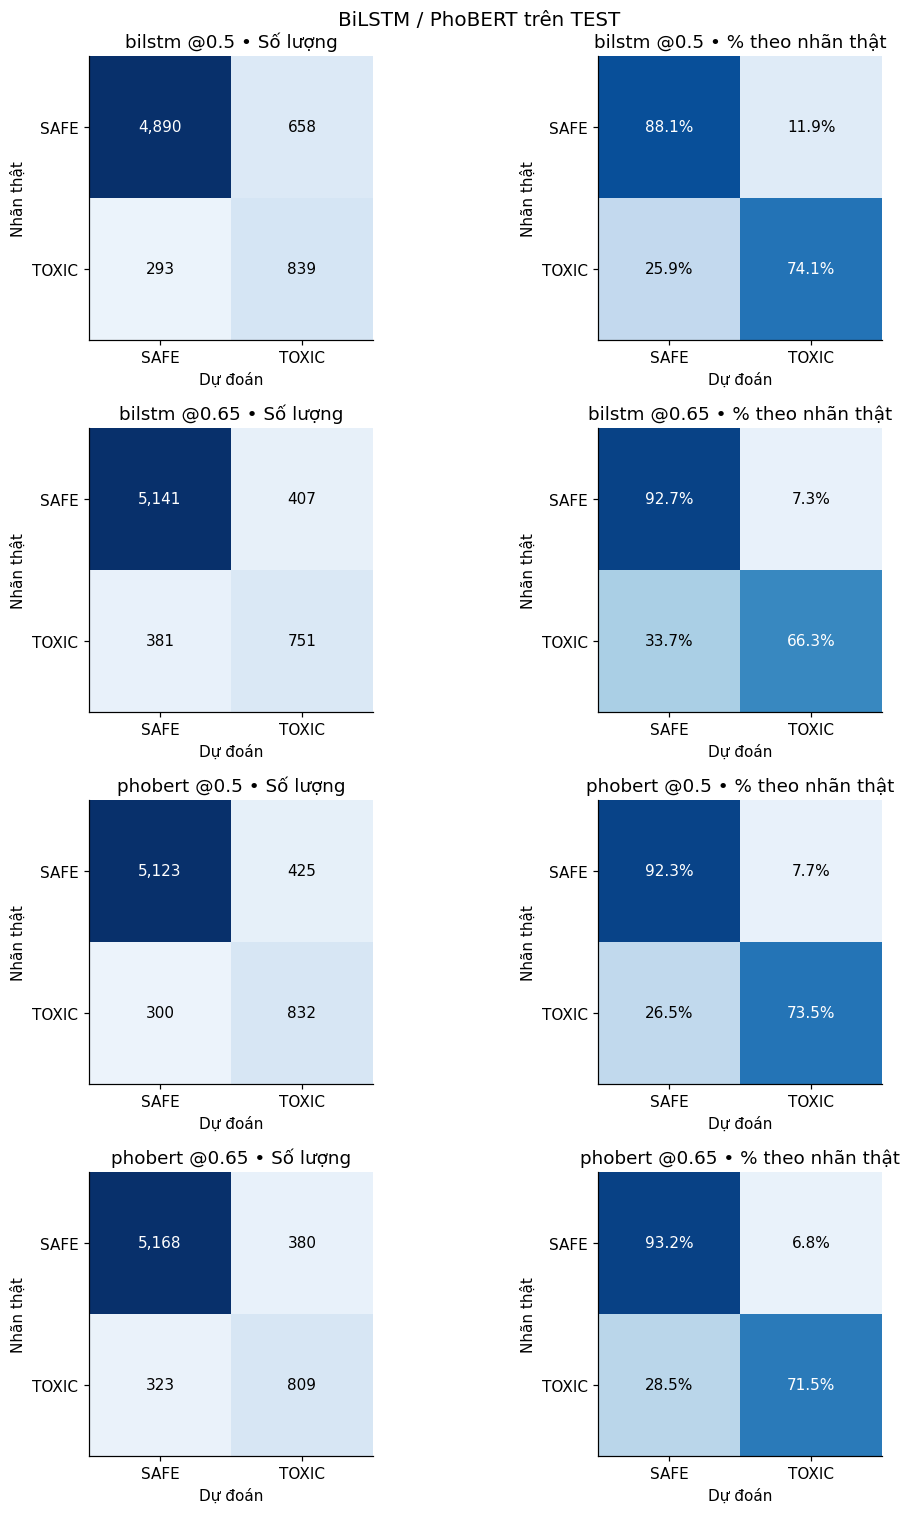


Ngưỡng quyết định tinh chỉnh trên DEV rồi áp nguyên vào TEST


model,threshold,chọn trên,tiêu chí,dev_macro_f1,dev_toxic_f1,test_macro_f1,test_toxic_recall,test_toxic_f1,test_macro_f1_@0.5
bilstm,0.6500,dev,toxic_f1,0.7902,0.6563,0.7924,0.6634,0.6559,0.7748
phobert,0.6500,dev,toxic_f1,0.8426,0.7429,0.8167,0.7147,0.6971,0.8152


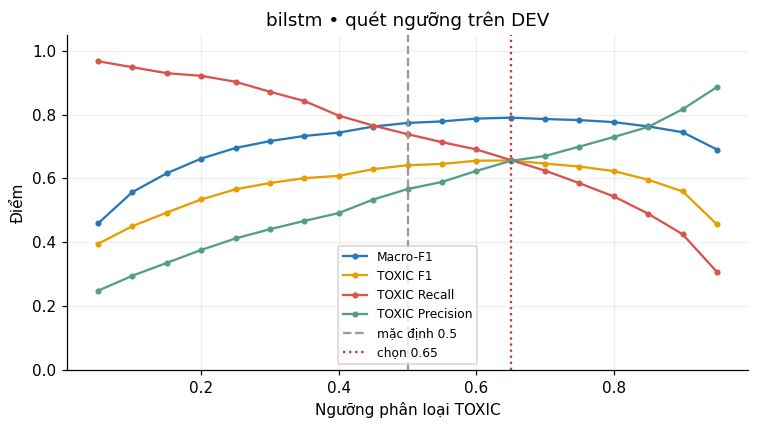

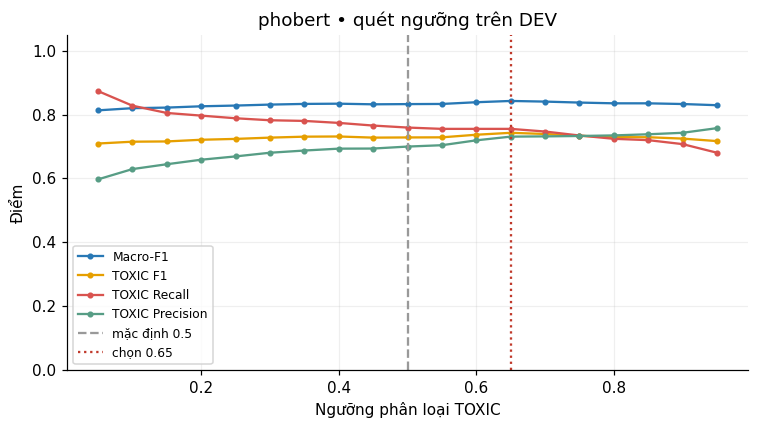

In [20]:
reports.neural_test(neural_test)

## 14. Tổng hợp và so sánh
Bảng tổng hợp dùng cùng tập **dev**. Model đứng đầu dev trong 5 mô hình không tự thay thế baseline test/demo.
Thời gian fit baseline gồm tiền xử lý + TF-IDF; neural là tổng bước tối ưu qua các epoch, không gồm tải checkpoint và tiền xử lý chung.
Vì vậy thời gian có mục đích mô tả lần chạy, không phải benchmark tốc độ công bằng giữa kiến trúc.


Bảng tổng hợp trên DEV (giá trị lưu không bị làm tròn)


model,type,best_epoch,train_macro_f1,dev_accuracy,dev_macro_f1,dev_toxic_recall,dev_toxic_f1,fit_seconds,evaluation_seconds,test_and_demo_model,test_accuracy,test_macro_f1,test_toxic_recall,test_toxic_f1,train_minus_dev_f1
phobert,Neural,3.0000,0.9183,0.8978,0.8327,0.7593,0.7284,773.0971,234.9445,False,0.8915,0.8152,0.7350,0.6965,0.0856
linear_svc,ML baseline,—,0.9602,0.8690,0.7923,0.7241,0.6660,16.1263,16.4925,True,0.8683,0.7785,0.6837,0.6376,0.1679
logistic_regression,ML baseline,—,0.9148,0.8630,0.7911,0.7656,0.6685,15.1772,16.8759,False,—,—,—,—,0.1237
bilstm,Neural,3.0000,0.8487,0.8510,0.7737,0.7386,0.6414,19.1271,5.0818,False,0.8576,0.7748,0.7412,0.6383,0.0750
multinomial_nb,ML baseline,—,0.8319,0.8641,0.6808,0.2946,0.4389,15.5650,17.2299,False,—,—,—,—,0.1511



Metrics tổng hợp (thang 0–1)


model,split,samples,accuracy,macro_precision,macro_recall,macro_f1,weighted_precision,weighted_recall,weighted_f1
linear_svc,dev,2672,0.8690,0.7767,0.8125,0.7923,0.8791,0.8690,0.8730
logistic_regression,dev,2672,0.8630,0.7691,0.8250,0.7911,0.8814,0.8630,0.8694
multinomial_nb,dev,2672,0.8641,0.8625,0.6421,0.6808,0.8637,0.8641,0.8355
bilstm,dev,2672,0.8510,0.7526,0.8072,0.7737,0.8713,0.8510,0.8583
phobert,dev,2672,0.8978,0.8229,0.8438,0.8327,0.9016,0.8978,0.8994



Precision / Recall / F1 / Support từng lớp


model,split,label,precision,recall,f1,support
linear_svc,dev,SAFE,0.9368,0.9009,0.9185,2190
linear_svc,dev,TOXIC,0.6166,0.7241,0.6660,482
logistic_regression,dev,SAFE,0.9449,0.8845,0.9137,2190
logistic_regression,dev,TOXIC,0.5932,0.7656,0.6685,482
multinomial_nb,dev,SAFE,0.8644,0.9895,0.9227,2190
multinomial_nb,dev,TOXIC,0.8606,0.2946,0.4389,482
bilstm,dev,SAFE,0.9384,0.8758,0.9060,2190
bilstm,dev,TOXIC,0.5669,0.7386,0.6414,482
phobert,dev,SAFE,0.9460,0.9283,0.9371,2190
phobert,dev,TOXIC,0.6998,0.7593,0.7284,482


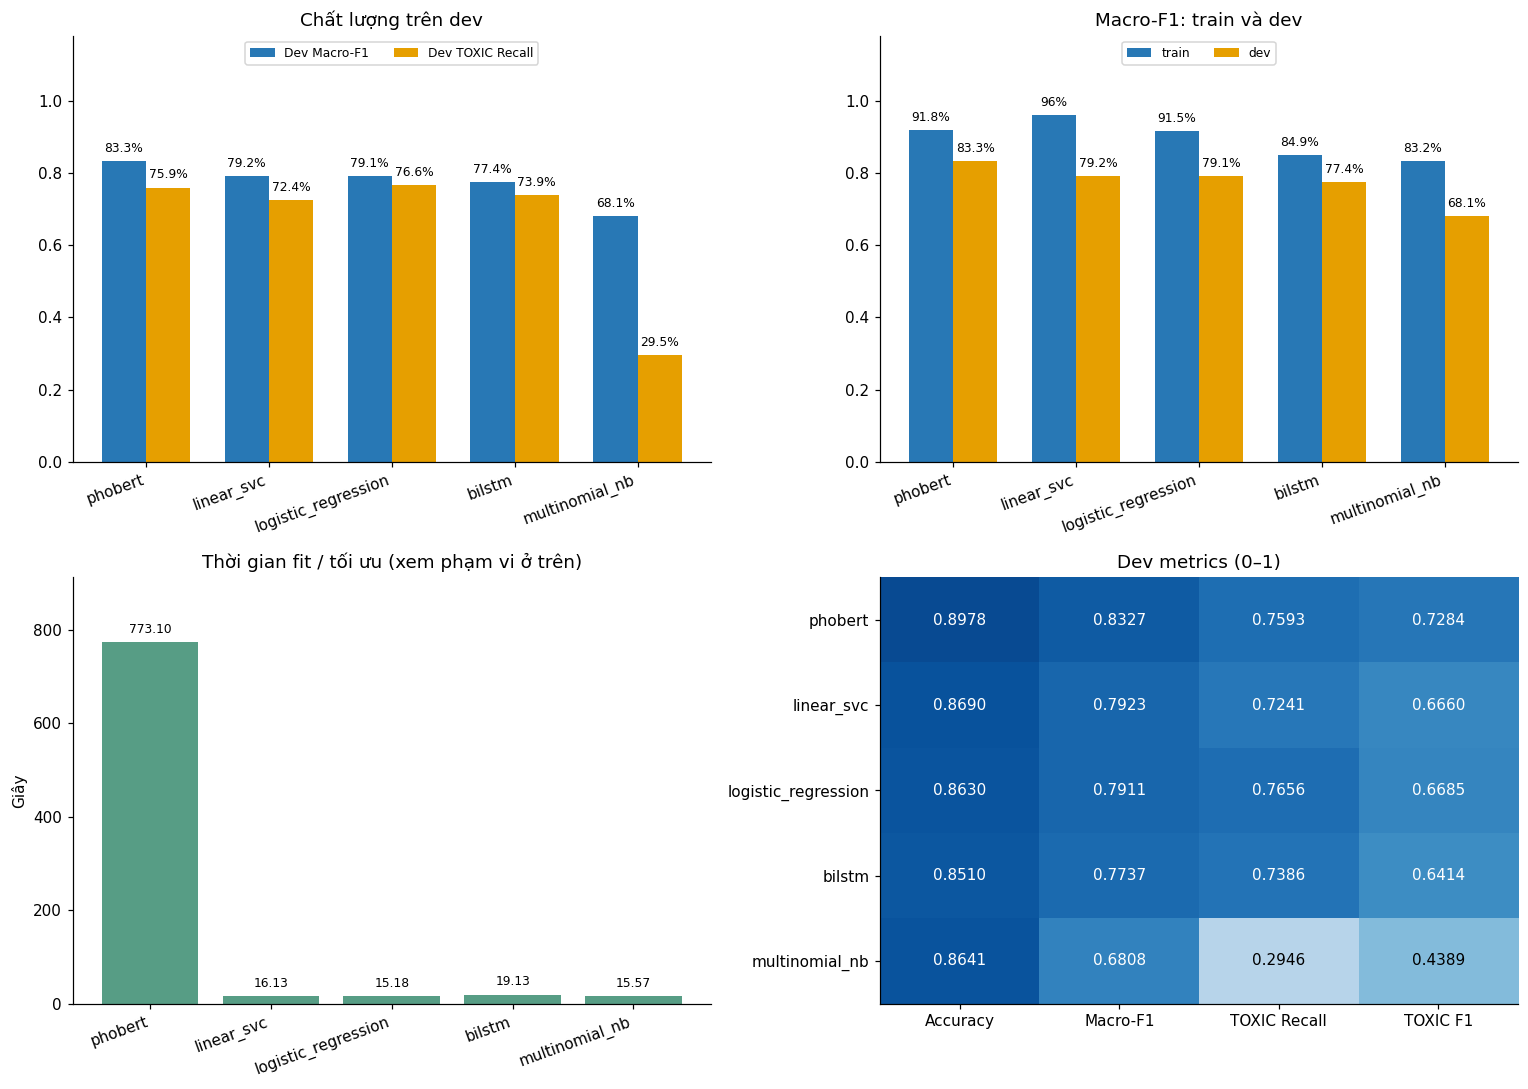

Model đứng đầu DEV: phobert (Macro-F1=0.8327)
Model TEST và DEMO đã khóa: linear_svc (test Accuracy=0.8683; test Macro-F1=0.7785)

Bảng so sánh trên TEST (baseline đã khóa + neural chấm sau khi khóa)


model,type,dev_macro_f1,test_accuracy,test_macro_f1,test_toxic_recall,test_toxic_f1
phobert,Neural,0.8327,0.8915,0.8152,0.7350,0.6965
linear_svc,ML baseline,0.7923,0.8683,0.7785,0.6837,0.6376
bilstm,Neural,0.7737,0.8576,0.7748,0.7412,0.6383


Model đứng đầu TEST: phobert (test Macro-F1=0.8152)


In [21]:
leaderboard = reports.comparison(baselines, neural, test, neural_test=neural_test)

## 15. Artifacts, tái lập và kết luận
Tất cả bảng/biểu đồ đã được xuất dưới dạng **CSV/PNG** trong thư mục lần chạy này; JSON giữ metrics đầy đủ.
`neural_history.json` chứa metrics train/dev của từng epoch, loss và thời gian. Checkpoint tốt nhất được lưu riêng.
Bảng dưới liệt kê đầy đủ đường dẫn, kích thước và loại file; file ZIP báo cáo gồm JSON/CSV/PNG, không gồm checkpoint lớn.
Kết quả là reproduction/post-hoc; không dùng kết quả test để điều chỉnh model trong lần chạy này.

In [22]:
report_archive = reports.export()


Các artifacts đã tạo (không liệt kê chính bảng inventory và ZIP tạo sau)


file,bytes,size_MiB,type,absolute_path
all_models_comparison.png,201633,0.1923,.png,/content/vihsd_ai_outputs/20260920T101602724213Z_full_with_neural/all_models_comparison.png
all_models_dev_leaderboard.csv,1366,0.0013,.csv,/content/vihsd_ai_outputs/20260920T101602724213Z_full_with_neural/all_models_dev_leaderboard.csv
all_models_dev_leaderboard.json,3265,0.0031,.json,/content/vihsd_ai_outputs/20260920T101602724213Z_full_with_neural/all_models_dev_leaderboard.json
all_models_dev_per_class.csv,879,0.0008,.csv,/content/vihsd_ai_outputs/20260920T101602724213Z_full_with_neural/all_models_dev_per_class.csv
all_models_dev_summary.csv,886,0.0008,.csv,/content/vihsd_ai_outputs/20260920T101602724213Z_full_with_neural/all_models_dev_summary.csv
all_models_test_leaderboard.csv,422,0.0004,.csv,/content/vihsd_ai_outputs/20260920T101602724213Z_full_with_neural/all_models_test_leaderboard.csv
audit_test.json,492,0.0005,.json,/content/vihsd_ai_outputs/20260920T101602724213Z_full_with_neural/audit_test.json
audit_test_distributions.png,65159,0.0621,.png,/content/vihsd_ai_outputs/20260920T101602724213Z_full_with_neural/audit_test_distributions.png
audit_test_labels.csv,314,0.0003,.csv,/content/vihsd_ai_outputs/20260920T101602724213Z_full_with_neural/audit_test_labels.csv
audit_test_stats.csv,205,0.0002,.csv,/content/vihsd_ai_outputs/20260920T101602724213Z_full_with_neural/audit_test_stats.csv


Đã lưu 73 artifacts trước inventory/ZIP.
Thư mục: /content/vihsd_ai_outputs/20260920T101602724213Z_full_with_neural
ZIP báo cáo: /content/vihsd_ai_outputs/20260920T101602724213Z_full_with_neural/reports.zip (1.30 MiB)
Colab: mở bảng Files bên trái → thư mục lần chạy → reports.zip → Download.


## 16. Ô thử nhanh — nhập câu mới và xem kết quả

Dùng để demo trực tiếp mà **không cần Run all**. Model đã nằm sẵn trong bộ nhớ ở biến
`test.model`, nên chỉ cần sửa câu rồi bấm chạy lại đúng cell bên dưới (`Shift + Enter`),
mất chưa tới một giây.

Điều kiện: đã chạy tới ít nhất **mục 9–10** trong phiên hiện tại. Nếu vừa Restart session
thì phải chạy lại từ đầu.


In [23]:
# ── THỬ NHIỀU CÂU CÙNG LÚC ──────────────────────────────────────────
# Sửa danh sách bên dưới rồi chạy lại CHỈ cell này.

cau_moi = [
    "Cảm ơn shop đã giao hàng nhanh, đóng gói rất cẩn thận.",
    "Nhóm mình vừa nộp đồ án xong, nhẹ cả người.",
    "Thằng này ngu như bò, nói mãi không hiểu.",
    "Phim này dở tệ, đạo diễn làm ăn kiểu gì vậy trời.",
    "Bạn nói cũng có lý nhưng mình nghĩ khác một chút.",
]

if "test" not in dir():
    raise RuntimeError(
        "Chưa có model trong bộ nhớ. Chạy các cell phía trên trước "
        "(Runtime > Run before), hoặc Run all nếu vừa Restart session."
    )

print(f"Model đang dùng: {test.model_name}")
print("=" * 76)
for i, cau in enumerate(cau_moi, 1):
    kq = system_decision(test.model, test.model_name, cau)
    dau = "[!]" if kq["label"] == "TOXIC" else "[ok]"
    print(f"{i}. {cau}")
    print(f"   {dau} {kq['label']:<5} | tin cay {kq['confidence_proxy']:.1%} "
          f"| muc {kq['warning_level']:<6} | can nguoi xem lai: "
          f"{'CO' if kq['human_review'] else 'khong'}")
    print()

Model đang dùng: linear_svc
1. Cảm ơn shop đã giao hàng nhanh, đóng gói rất cẩn thận.
   [ok] SAFE  | tin cay 76.1% | muc LOW    | can nguoi xem lai: khong

2. Nhóm mình vừa nộp đồ án xong, nhẹ cả người.
   [ok] SAFE  | tin cay 60.1% | muc REVIEW | can nguoi xem lai: CO

3. Thằng này ngu như bò, nói mãi không hiểu.
   [!] TOXIC | tin cay 91.9% | muc HIGH   | can nguoi xem lai: CO

4. Phim này dở tệ, đạo diễn làm ăn kiểu gì vậy trời.
   [ok] SAFE  | tin cay 73.3% | muc LOW    | can nguoi xem lai: khong

5. Bạn nói cũng có lý nhưng mình nghĩ khác một chút.
   [ok] SAFE  | tin cay 78.7% | muc LOW    | can nguoi xem lai: khong

